In [16]:
import torch
from matplotlib import pyplot as plt
import numpy as np

from models.vqvae import VQVAE
from dataset.vae_dataset import VAEDataset


torch.set_float32_matmul_precision("medium")

model = VQVAE.load_from_checkpoint(
    "logs/vqvae_5channel/version_46/checkpoints/epoch=201-step=4751.ckpt",
    in_channels=5,
)
model = model.cpu()

ds = VAEDataset(path="train.memmap", channels=5, img_res=(128, 64))

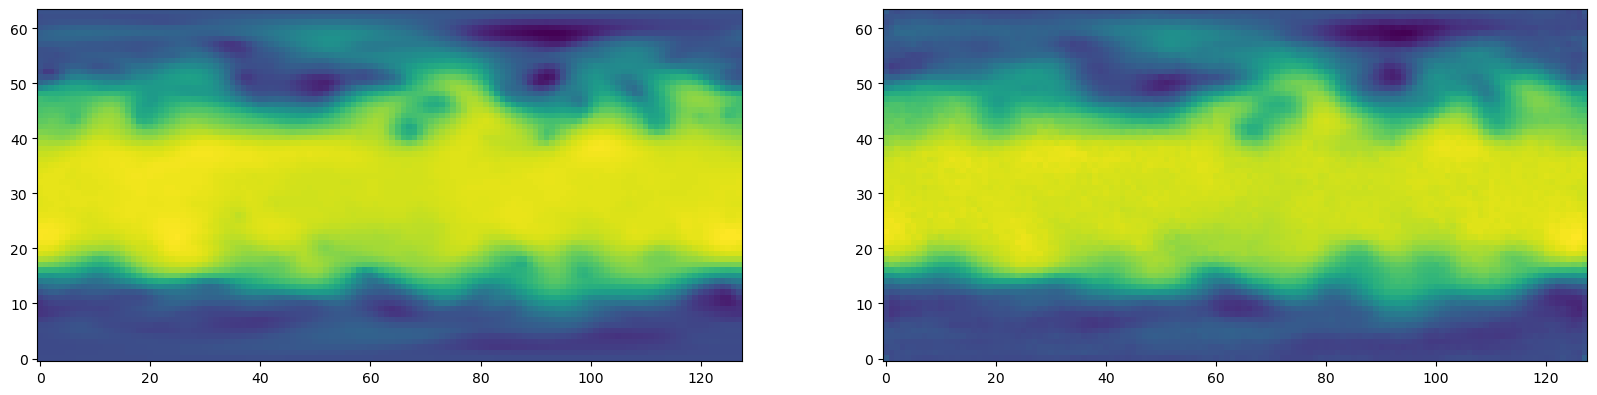

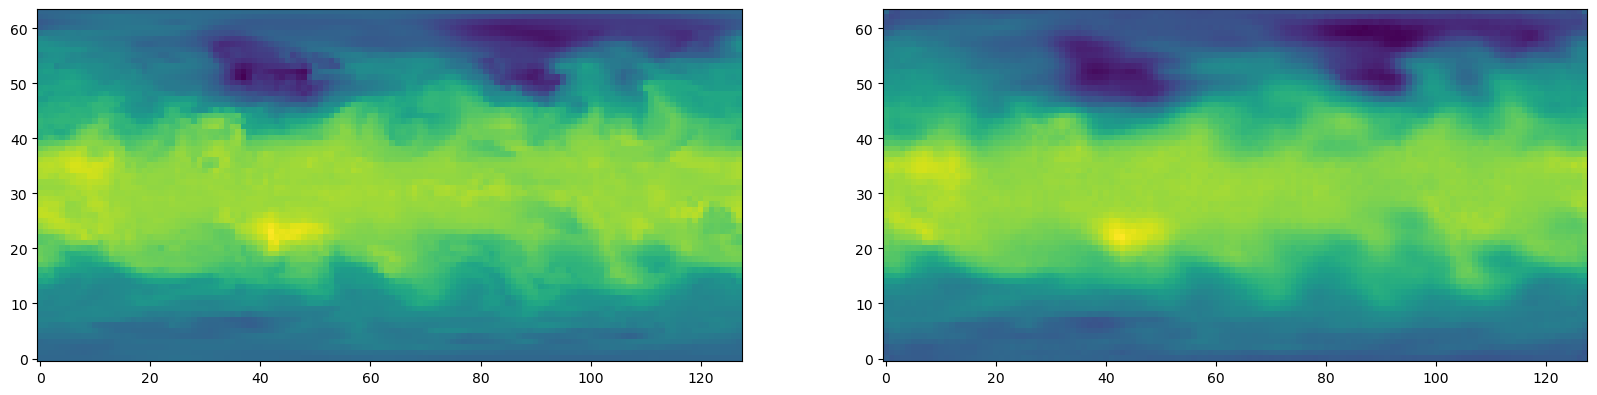

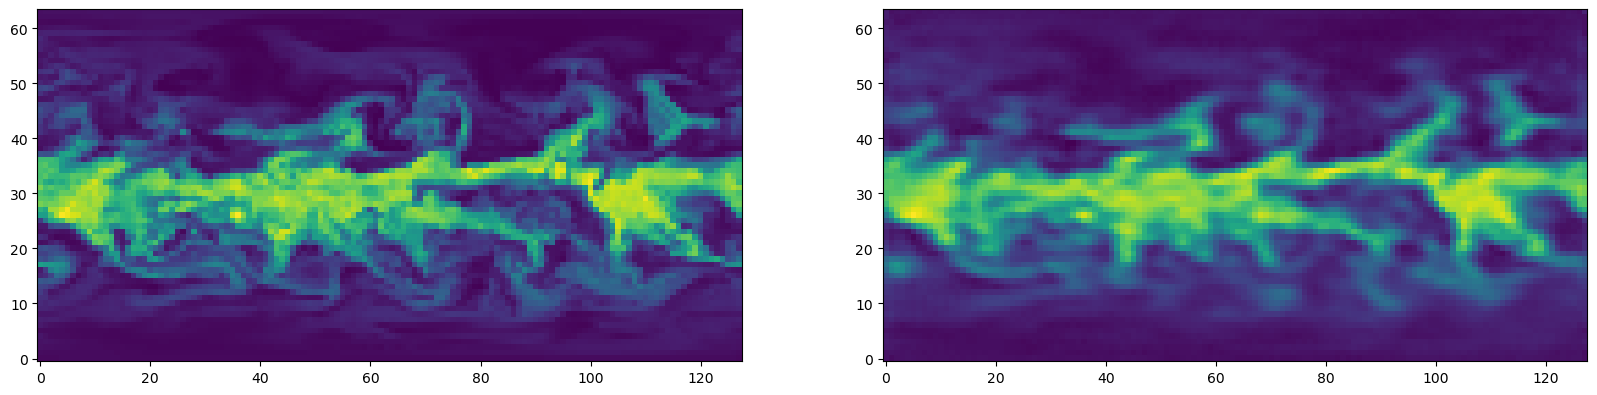

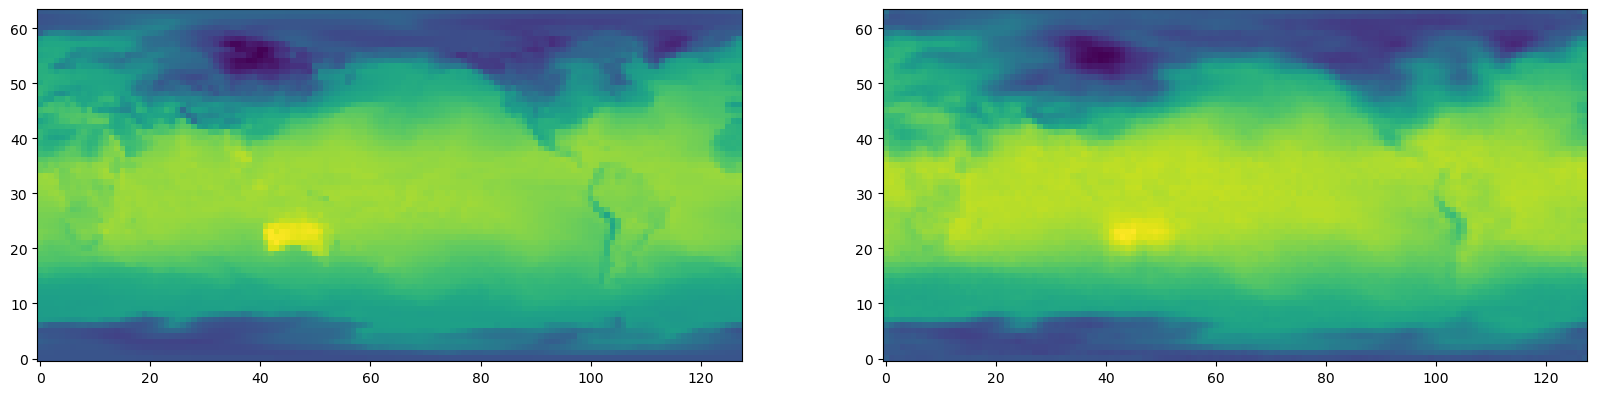

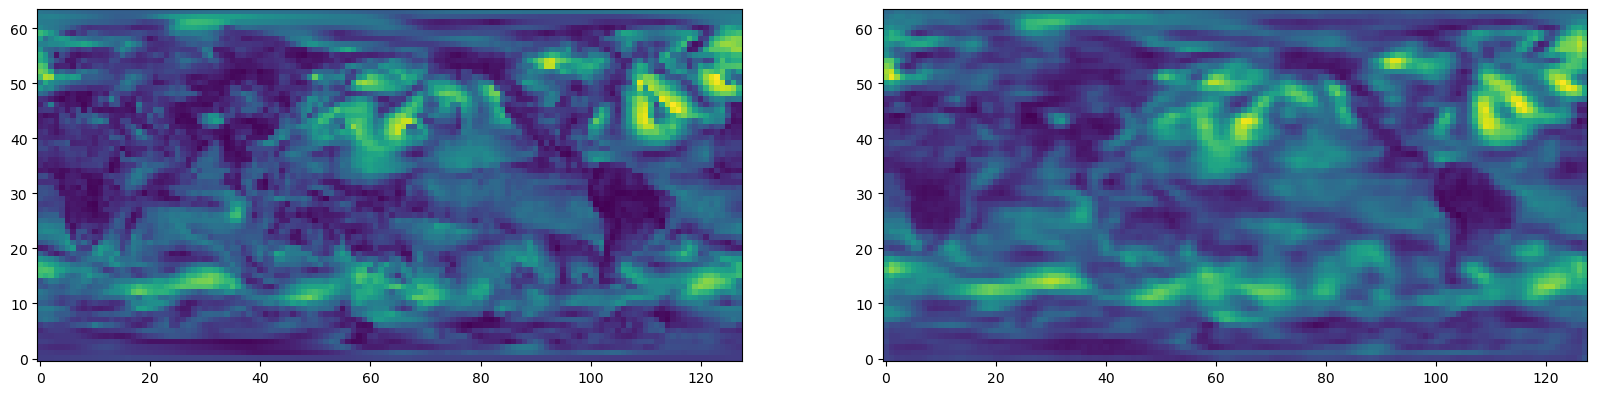

In [17]:
sample = torch.Tensor(ds[1])

prediction = model(sample.unsqueeze(0))

for i in range(5):
    fig, axs = plt.subplots(1, 2, figsize=(20, 10))
    axs[0].imshow(sample[i].numpy().T, origin="lower")
    axs[1].imshow(prediction[0][0][i].detach().numpy().T, origin="lower")
    plt.show()

torch.Size([1, 5, 128, 64]) torch.Size([1, 5, 128, 64])


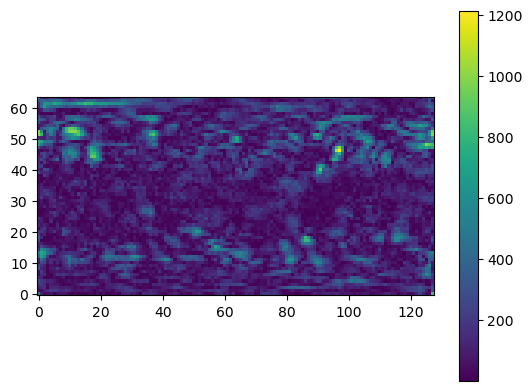

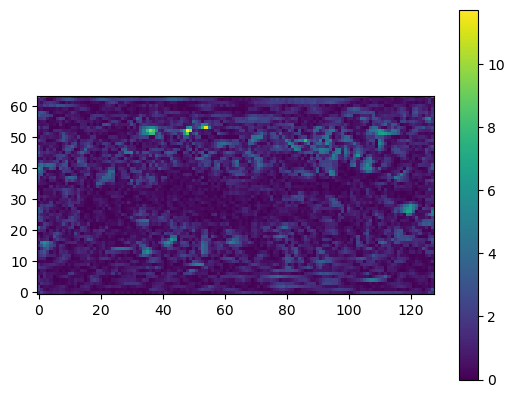

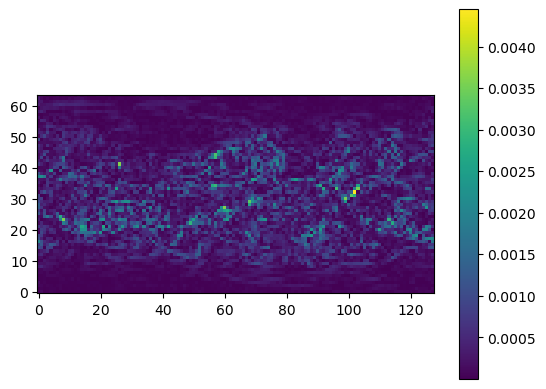

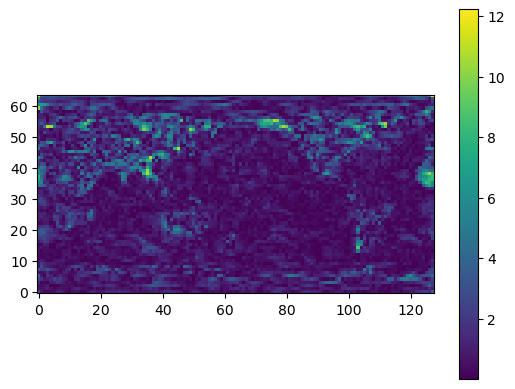

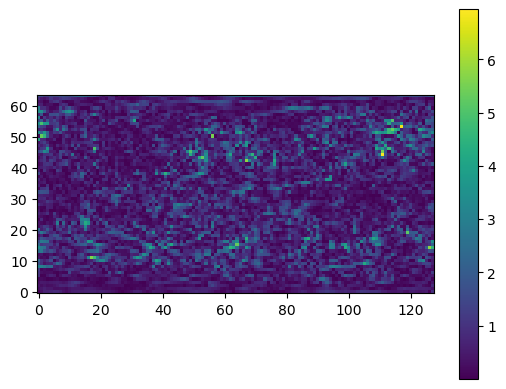

RMSE: 195.39547729492188


In [19]:
sample = torch.Tensor(ds[0]).unsqueeze(0)

prediction, latent, _ = model(sample)

print(sample.shape, prediction.shape)

sample = ds.denormalize_sample(sample.detach().numpy())
prediction = ds.denormalize_sample(prediction.detach().numpy())

for i in range(5):
    img = np.sqrt((sample[0][i].T - prediction[0][i].T)**2)
    # range between 0 and 1
    plt.imshow(img, origin="lower")
    plt.colorbar()
    plt.show()

t2m_rmse = np.sqrt(np.mean((sample[0][0].T - prediction[0][0].T)**2))
print(f"RMSE: {t2m_rmse}")

Euklid: 5.893607139587402


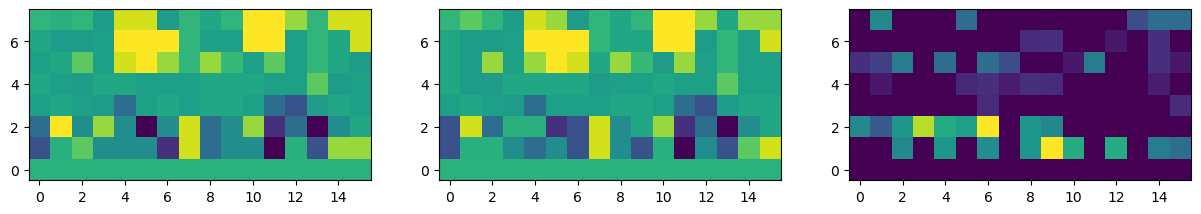

In [27]:
sample_1 = torch.Tensor(ds[0]).unsqueeze(0)
sample_2 = torch.Tensor(ds[1]).unsqueeze(0)

_, latent_1, _ = model(sample_1)
_, latent_2, _ = model(sample_2)

diff = np.sqrt((latent_1[0] - latent_2[0]).detach().numpy()**2)

euklid = np.sqrt(np.sum(diff**2))
print(f"Euklid: {euklid}")

for i in range(1):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(latent_1[0][i].detach().numpy().T, origin="lower")
    axs[1].imshow(latent_2[0][i].detach().numpy().T, origin="lower")
    axs[2].imshow(diff[i].T, origin="lower")
    plt.show()